In [ ]:
# ---------------------------
# CÉLULA 1: INSTALAÇÃO DE DEPENDÊNCIAS
# Execute esta célula primeiro no notebook
# ---------------------------
!pip install --upgrade pip
!pip install transformers sentencepiece sacremoses accelerate datasets
# Instala torch (CPU por padrão). Se quiser versão CUDA, troque conforme instruções do site do PyTorch.
!pip install torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 12.5 MB/s  0:00:00


In [ ]:
# ---------------------------
# CÉLULA 2: CÓDIGO COMPLETO (TRADUÇÃO COM 4 MODELOS)
# ---------------------------

import re, textwrap
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import pandas as pd
from typing import List

# Detecta dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# Modelos
MODELOS = {
    "NLLB": "facebook/nllb-200-distilled-600M",
    "M2M100-418M": "facebook/m2m100_418M",
    "FLAN-T5": "google/flan-t5-large",
    "MBART": "facebook/mbart-large-50-many-to-many-mmt"
}

# Carrega tokenizers / modelos (lazy loading para reduzir memória inicial)
def load_tokenizer_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    model.to(device)
    return tokenizer, model

# Função de split em sentenças simples
def split_into_sentences(text: str) -> List[str]:
    text = text.strip()
    sents = re.split(r'(?<=[\.\?\!])\s+(?=[^\s])', text)
    sents = [s.strip() for s in sents if s.strip()]
    return sents

# Chunking por tokens estimados via tokenizer
def chunk_sentences_by_token_limit(sentences: List[str], tokenizer, max_tokens:int=400) -> List[str]:
    chunks=[]
    cur=[]
    cur_toks=0
    for s in sentences:
        toks=len(tokenizer.tokenize(s))
        if toks>max_tokens:
            if cur:
                chunks.append(" ".join(cur)); cur=[]; cur_toks=0
            words=s.split()
            piece=[]; piece_toks=0
            for w in words:
                wtoks=len(tokenizer.tokenize(w))
                if piece_toks + wtoks > max_tokens:
                    if piece: chunks.append(" ".join(piece))
                    piece=[w]; piece_toks=wtoks
                else:
                    piece.append(w); piece_toks+=wtoks
            if piece: chunks.append(" ".join(piece))
            continue
        if cur_toks + toks <= max_tokens:
            cur.append(s); cur_toks+=toks
        else:
            if cur: chunks.append(" ".join(cur))
            cur=[s]; cur_toks=toks
    if cur: chunks.append(" ".join(cur))
    return chunks

# Tradução com pipeline (NLLB, M2M100, MBART) - usa pipeline do transformers
def translate_with_pipeline_chunks(text, tokenizer, pipeline_model, src_lang=None, tgt_lang=None, max_tokens=350):
    sents = split_into_sentences(text)
    chunks = chunk_sentences_by_token_limit(sents, tokenizer, max_tokens=max_tokens)
    translations=[]
    for c in chunks:
        kwargs={}
        if src_lang is not None: kwargs["src_lang"]=src_lang
        if tgt_lang is not None: kwargs["tgt_lang"]=tgt_lang
        out = pipeline_model(c, **kwargs) if kwargs else pipeline_model(c)
        if isinstance(out, list):
            translations.append(out[0].get("translation_text", out[0].get("text","")))
        elif isinstance(out, dict):
            translations.append(out.get("translation_text",""))
        else:
            translations.append(str(out))
    return " ".join(translations)

# Tradução com FLAN-T5 via generate (prompt)
def translate_with_flan_chunks(text, tokenizer, model, max_tokens=250):
    sents = split_into_sentences(text)
    chunks = chunk_sentences_by_token_limit(sents, tokenizer, max_tokens=max_tokens)
    translations=[]
    for c in chunks:
        prompt = f"Translate the following text from Portuguese to English:\n\n{c}\n\nTranslate:"
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(device)
        outputs = model.generate(**inputs, max_length=1024, num_beams=4, early_stopping=True)
        txt = tokenizer.decode(outputs[0], skip_special_tokens=True)
        translations.append(txt)
    return " ".join(translations)

# Função central: traduz com os 4 modelos
def translate_text_all_models(text: str, src="pt", tgt="en"):
    # códigos NLLB e MBART
    nllb_codes = {"pt":"por_Latn","en":"eng_Latn"}
    mbart_codes = {"pt":"pt_XX","en":"en_XX"}

    # Carrega / cria pipelines (lazy)
    # NLLB
    tok_nllb, _ = load_tokenizer_model(MODELOS["NLLB"])
    pipe_nllb = pipeline("translation", model=MODELOS["NLLB"], tokenizer=tok_nllb, device=0 if device=="cuda" else -1)

    # M2M100
    tok_m2m, _ = load_tokenizer_model(MODELOS["M2M100-418M"])
    pipe_m2m = pipeline("translation", model=MODELOS["M2M100-418M"], tokenizer=tok_m2m, device=0 if device=="cuda" else -1)

    # FLAN-T5 (carregar modelo/tokenizer)
    tok_flan, model_flan = load_tokenizer_model(MODELOS["FLAN-T5"])

    # MBART
    tok_mbart, _ = load_tokenizer_model(MODELOS["MBART"])
    pipe_mbart = pipeline("translation", model=MODELOS["MBART"], tokenizer=tok_mbart, device=0 if device=="cuda" else -1)

    # NLLB
    nllb_trans = translate_with_pipeline_chunks(text, tok_nllb, pipe_nllb, src_lang=nllb_codes.get(src), tgt_lang=nllb_codes.get(tgt), max_tokens=350)
    # M2M100
    m2m_trans  = translate_with_pipeline_chunks(text, tok_m2m, pipe_m2m, src_lang=src, tgt_lang=tgt, max_tokens=350)
    # FLAN-T5
    flan_trans = translate_with_flan_chunks(text, tok_flan, model_flan, max_tokens=250)
    # MBART
    mbart_trans = translate_with_pipeline_chunks(text, tok_mbart, pipe_mbart, src_lang=mbart_codes.get(src), tgt_lang=mbart_codes.get(tgt), max_tokens=350)

    return {
        "NLLB": nllb_trans,
        "M2M100_418M": m2m_trans,
        "FLAN_T5": flan_trans,
        "MBART": mbart_trans
    }

# Exemplos de métricas simples
def jaccard_similarity(a: str, b: str) -> float:
    sa=set(a.lower().split()); sb=set(b.lower().split())
    if not sa and not sb: return 1.0
    if not sa or not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

def overlap_ratio(a: str, b: str) -> float:
    ta=a.lower().split(); tb=set(b.lower().split())
    if not ta: return 0.0
    return sum(1 for t in ta if t in tb) / len(ta)

# Função processadora de pares REF x AUTO
def process_pairs(ref_texts, auto_texts, src="pt", tgt="en"):
    rows=[]
    n=min(len(ref_texts), len(auto_texts))
    for i in range(n):
        ref=ref_texts[i]; auto=auto_texts[i]
        tr_ref = translate_text_all_models(ref, src=src, tgt=tgt)
        tr_auto = translate_text_all_models(auto, src=src, tgt=tgt)
        for model_name in tr_ref.keys():
            ref_tr = tr_ref[model_name]; auto_tr = tr_auto[model_name]
            rows.append({
                "Paragrafo_Index": i+1,
                "Modelo": model_name,
                "REF_pt": ref,
                "AUTO_pt": auto,
                "REF_tr": ref_tr,
                "AUTO_tr": auto_tr,
                "Jaccard": jaccard_similarity(ref_tr, auto_tr),
                "Overlap_ratio": overlap_ratio(ref_tr, auto_tr)
            })
    return pd.DataFrame(rows)

# ---------------------------
# EXEMPLO (substitua REF e AUTO pelas suas listas)
# ---------------------------
if __name__ == "__main__":
    REF = [
        "Exemplo longo de referência. Este parágrafo pode ter mais de mil palavras — o código fará chunking automaticamente.",
        "Segundo parágrafo de referência para teste."
    ]
    AUTO = [
        "Exemplo longo gerado automaticamente. Também pode exceder limites e será dividido.",
        "Segundo parágrafo automático."
    ]
    df = process_pairs(REF, AUTO, src="pt", tgt="en")
    print(df.head())
    df.to_csv("comparativo_traducao_4_modelos.csv", index=False)
    print("Salvo: comparativo_traducao_4_modelos.csv")


Usando dispositivo: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu


   Paragrafo_Index       Modelo  \
0                1         NLLB   
1                1  M2M100_418M   
2                1      FLAN_T5   
3                1        MBART   
4                2         NLLB   

                                              REF_pt  \
0  Exemplo longo de referência. Este parágrafo po...   
1  Exemplo longo de referência. Este parágrafo po...   
2  Exemplo longo de referência. Este parágrafo po...   
3  Exemplo longo de referência. Este parágrafo po...   
4        Segundo parágrafo de referência para teste.   

                                             AUTO_pt  \
0  Exemplo longo gerado automaticamente. Também p...   
1  Exemplo longo gerado automaticamente. Também p...   
2  Exemplo longo gerado automaticamente. Também p...   
3  Exemplo longo gerado automaticamente. Também p...   
4                      Segundo parágrafo automático.   

                                              REF_tr  \
0  This paragraph can have more than a thousand w...   
1  

In [ ]:
def plot_metricas_medias(df, metrica):
    import matplotlib.pyplot as plt
    import seaborn as sns

    medias = df.groupby("Modelo")[metrica].mean().sort_values()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=medias.values, y=medias.index, palette="Set2")

    plt.title(f"Média de {metrica} por Modelo", fontsize=18)
    plt.xlabel(metrica)
    plt.ylabel("Modelo")

    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-53008428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medias.values, y=medias.index, palette="Set2")


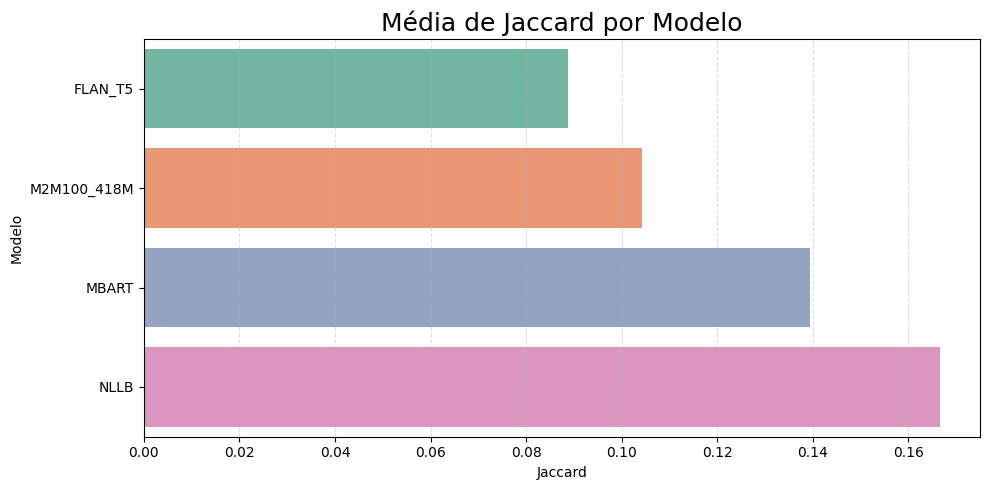

In [ ]:
plot_metricas_medias(df, "Jaccard")